In [1]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

In [9]:
REPORT_TAGNAME = "2024_11_09_v1"

In [10]:
def show_accuracy(accuracy_list):
    print("Accuracy List:", accuracy_list)
    print("Accuracy mean:", np.array(accuracy_list).mean())


In [11]:
def show_loss(loss_list):
    print("Loss List:", loss_list)
    print("Loss mean:", np.array(loss_list).mean())

In [12]:
def display_classification_reports(classification_reports, mappings):
    for i, report in enumerate(classification_reports):
        dfReport = pd.DataFrame(report).transpose()
        dfReport.rename(index=mappings, inplace=True)
        print(f"\nClassification Report {i+1}:")
        print(dfReport)

In [13]:
def plot_history(history):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history["accuracy"])
    plt.plot(history["val_accuracy"])
    plt.title("Model accuracy")
    plt.ylabel("Accuracy")
    plt.xlabel("Epoch")
    plt.legend(["Train", "Validation"], loc="upper left")

    plt.subplot(1, 2, 2)
    plt.plot(history["loss"])
    plt.plot(history["val_loss"])
    plt.title("Model loss")
    plt.ylabel("Loss")
    plt.xlabel("Epoch")
    plt.legend(["Train", "Validation"], loc="upper left")

    plt.show()

In [14]:
def plot_confusion(confusion_matrices, mappings):
    for i, conf_matrix in enumerate(confusion_matrices):
        conf_matrix = np.array(conf_matrix)
        if conf_matrix.ndim == 1:
            conf_matrix = conf_matrix.reshape(-1, 1)
        
        labels = [mappings[str(i)] for i in range(len(mappings))]
        
        plt.figure(figsize=(10, 8))
        sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
        plt.yticks(rotation=45)
        plt.title(f"Cross validation {i+1}")
        plt.xlabel("Predicted Labels")
        plt.ylabel("True Labels")
        plt.show()

# Download data

In [15]:
with open(os.path.join("models", REPORT_TAGNAME ,"raport.json"), "r") as file:
    data = json.load(file)

# Show reports

## Show accuracy and loss

In [16]:
show_accuracy(data['accuracy_list'])
show_loss(data['loss_list'])

Accuracy List: [0.9839882254600525, 0.9824411869049072, 0.9817450642585754, 0.9835241436958313, 0.9825959205627441]
Accuracy mean: 0.9828589081764221
Loss List: [0.05531268194317818, 0.06239018216729164, 0.054293762892484665, 0.05325010046362877, 0.05360591411590576]
Loss mean: 0.0557705283164978


## Classification reports

In [17]:
display_classification_reports(data['classification_reports'], data['mappings'])


Classification Report 1:
              precision    recall  f1-score       support
piccolo        0.983553  0.985173  0.984362    607.000000
clarinet       0.990103  0.975619  0.982807   2666.000000
bass           0.993243  0.967105  0.980000    152.000000
flute          0.954569  0.981944  0.968063   1883.000000
oboe           0.992574  0.990123  0.991347    405.000000
cello          0.995821  0.989324  0.992562   1686.000000
violin         0.993445  0.996348  0.994894   1369.000000
sax            0.986880  0.990128  0.988502   2735.000000
trumpet        0.980878  0.971930  0.976384   1425.000000
accuracy       0.983988  0.983988  0.983988      0.983988
macro avg      0.985674  0.983077  0.984325  12928.000000
weighted avg   0.984135  0.983988  0.984016  12928.000000

Classification Report 2:
              precision    recall  f1-score       support
piccolo        0.991453  0.976431  0.983885    594.000000
clarinet       0.987528  0.973184  0.980304   2685.000000
bass           1.000

## Confusion matrix

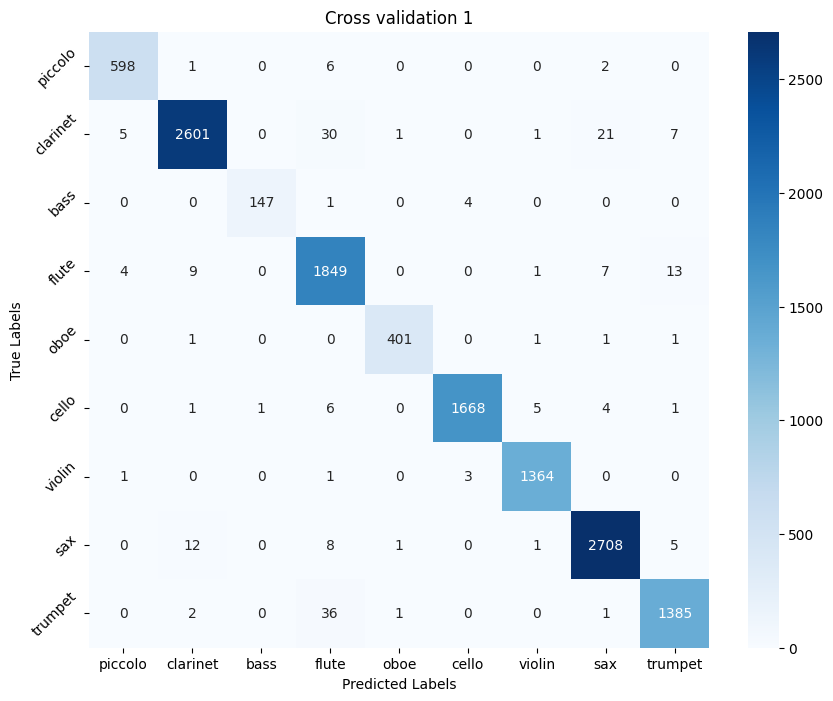

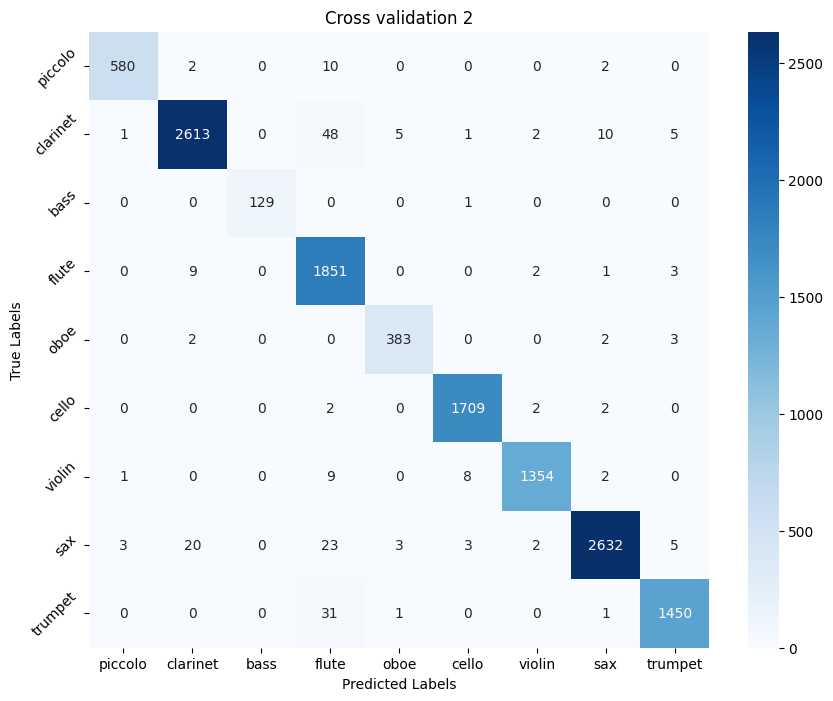

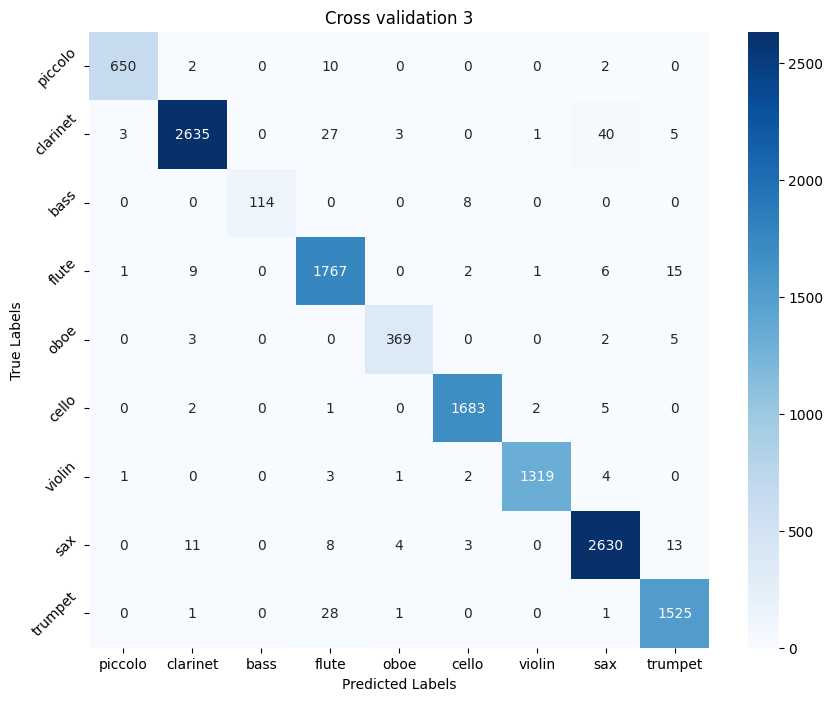

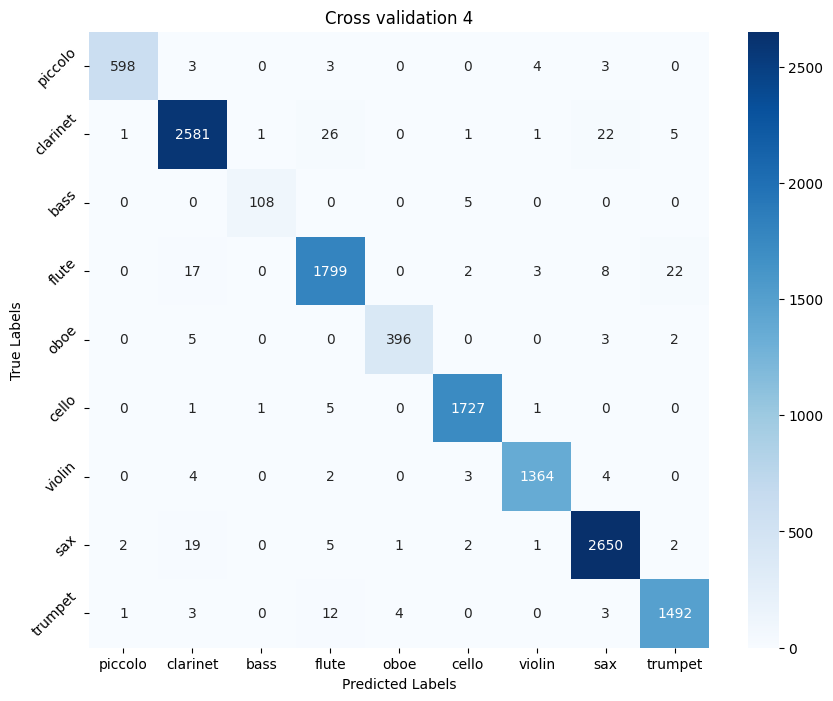

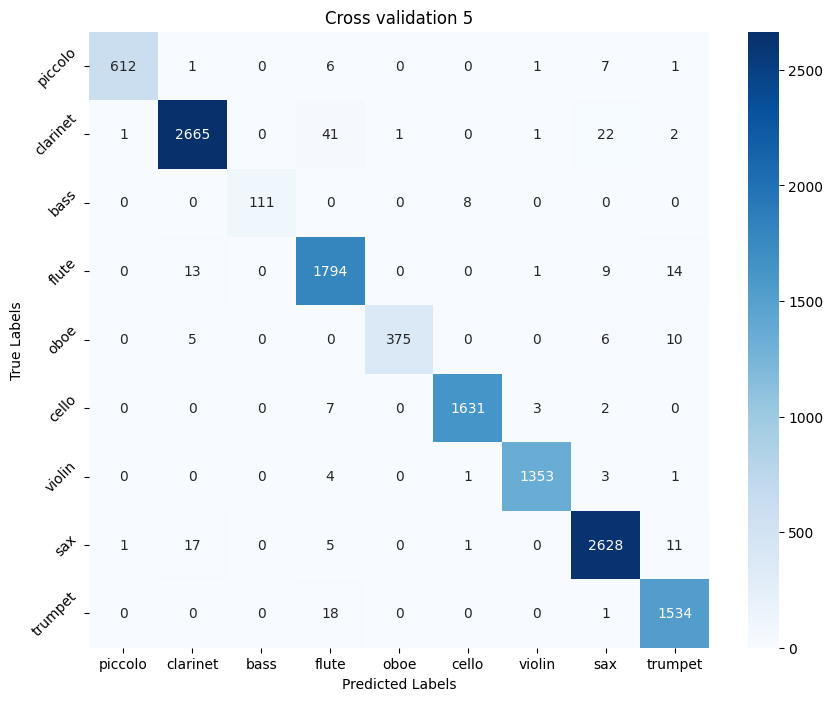

In [18]:
plot_confusion(data['confusion_matrices'], data['mappings'])

## Training history

Cross validation training 1


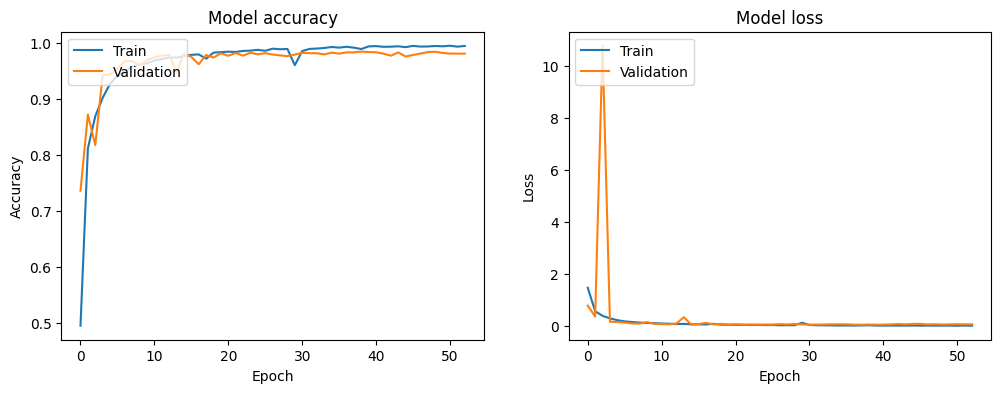

Cross validation training 2


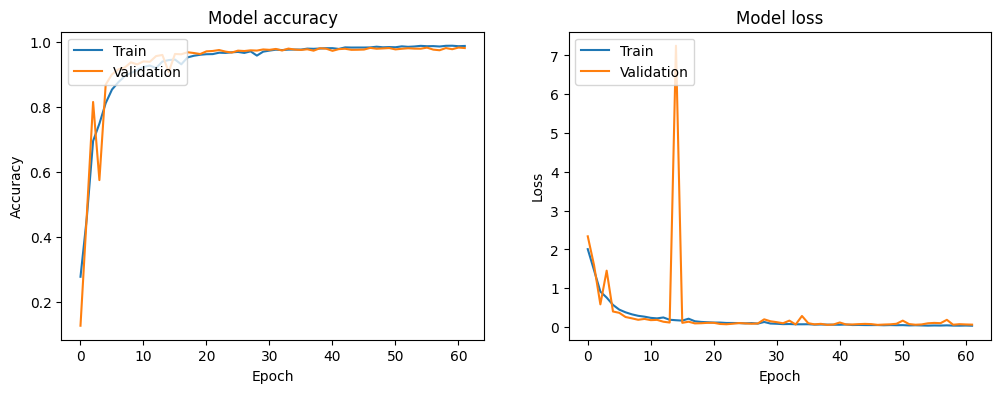

Cross validation training 3


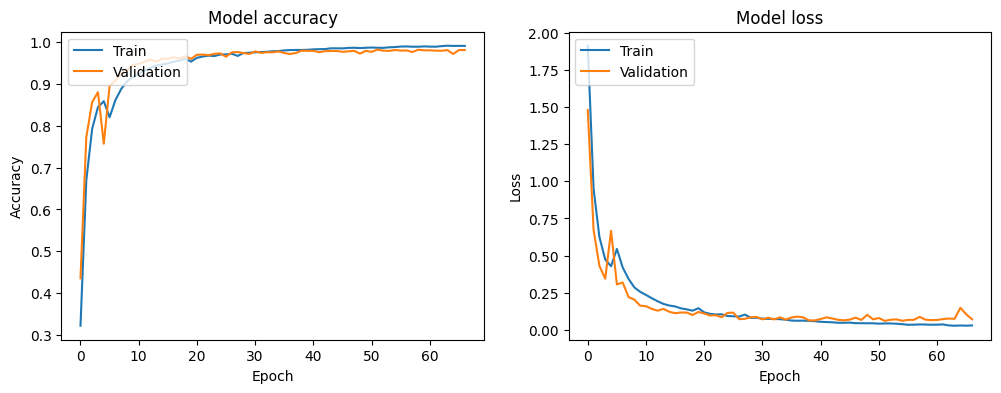

Cross validation training 4


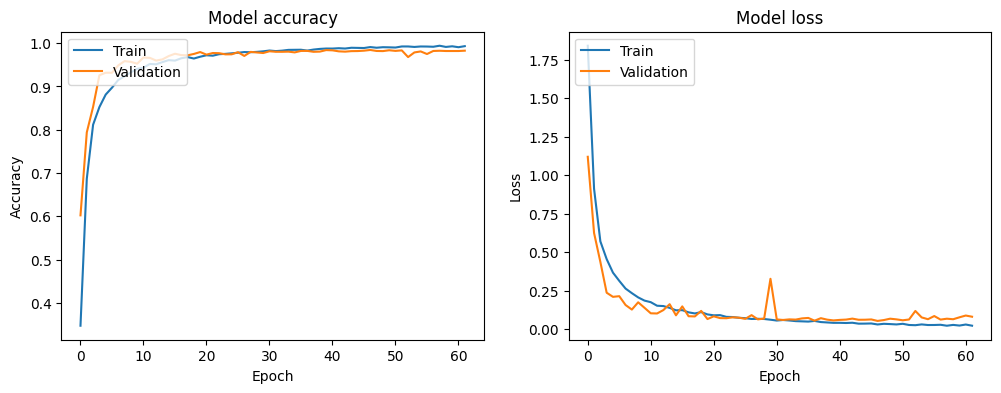

Cross validation training 5


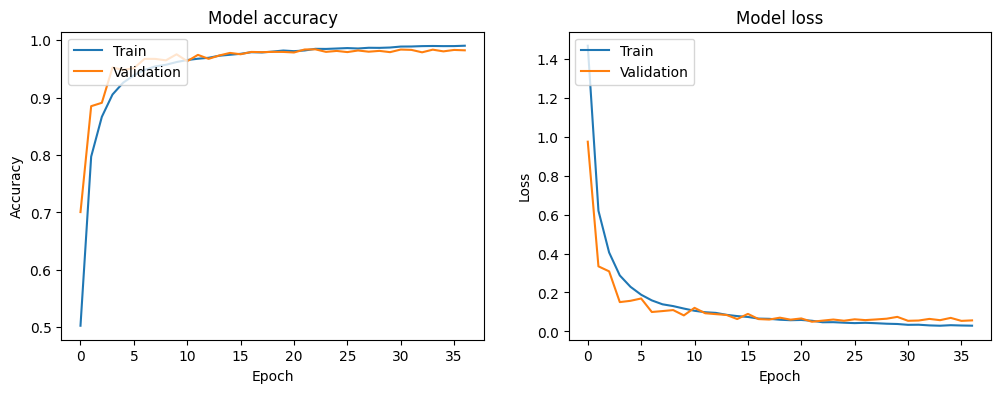

In [19]:
for i, history in enumerate(data['histories']):
    print(f"Cross validation training {i+1}")
    plot_history(history)